In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/brain-tumor-mri-scans/pituitary/0664.jpg
/kaggle/input/brain-tumor-mri-scans/pituitary/1269.jpg
/kaggle/input/brain-tumor-mri-scans/pituitary/0733.jpg
/kaggle/input/brain-tumor-mri-scans/pituitary/0106.jpg
/kaggle/input/brain-tumor-mri-scans/pituitary/0375.jpg
/kaggle/input/brain-tumor-mri-scans/pituitary/1700.jpg
/kaggle/input/brain-tumor-mri-scans/pituitary/1075.jpg
/kaggle/input/brain-tumor-mri-scans/pituitary/0285.jpg
/kaggle/input/brain-tumor-mri-scans/pituitary/0591.jpg
/kaggle/input/brain-tumor-mri-scans/pituitary/0799.jpg
/kaggle/input/brain-tumor-mri-scans/pituitary/1411.jpg
/kaggle/input/brain-tumor-mri-scans/pituitary/0074.jpg
/kaggle/input/brain-tumor-mri-scans/pituitary/1031.jpg
/kaggle/input/brain-tumor-mri-scans/pituitary/0077.jpg
/kaggle/input/brain-tumor-mri-scans/pituitary/0498.jpg
/kaggle/input/brain-tumor-mri-scans/pituitary/1749.jpg
/kaggle/input/brain-tumor-mri-scans/pituitary/0610.jpg
/kaggle/input/brain-tumor-mri-scans/pituitary/1501.jpg
/kaggle/in

In [2]:
import tensorflow as tf
import numpy as np
import random
import os

# 1. Set Python, NumPy, and TensorFlow seeds
seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# 2. Force GPU deterministic ops (optional, slows training slightly)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# 3. Confirm TensorFlow sees GPU
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


2025-12-27 15:07:39.486268: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766848059.671816      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766848059.728763      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766848060.209003      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766848060.209068      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766848060.209071      55 computation_placer.cc:177] computation placer alr

Num GPUs Available: 1


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [4]:
def load_data(data_dir, img_size=(128, 128)):
    images, labels = [], []
    class_names = []
    for label, class_name in enumerate(sorted(os.listdir(data_dir))):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        class_names.append(class_name)
        for img_name in os.listdir(class_path):
            try:
                img = keras.preprocessing.image.load_img(
                    os.path.join(class_path, img_name),
                    target_size=img_size
                )
                img = keras.preprocessing.image.img_to_array(img)
                images.append(img)
                labels.append(label)
            except:
                pass
    return np.array(images), np.array(labels), class_names

DATA_DIR = "/kaggle/input/brain-tumor-mri-scans"
X, y, class_names = load_data(DATA_DIR, img_size=(128, 128))
X = X / 255.0



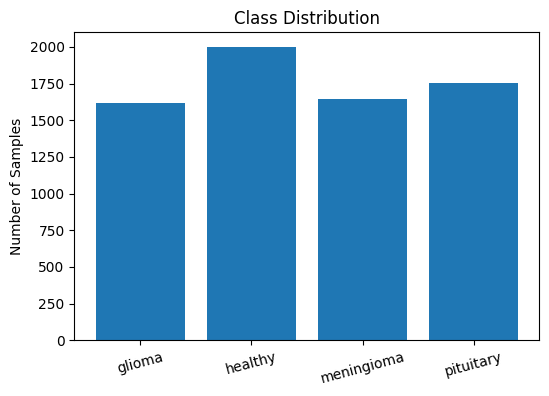

In [5]:
# Class distribution
class_counts = {name: 0 for name in class_names}
for label in y:
    class_counts[class_names[label]] += 1

plt.figure(figsize=(6,4))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution")
plt.ylabel("Number of Samples")
plt.xticks(rotation=15)
plt.show()


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)
print(f"Data loaded: {X.shape}")
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Classes: {class_names}")

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

Data loaded: (7023, 128, 128, 3)
Train: (4916, 128, 128, 3), Val: (1053, 128, 128, 3), Test: (1054, 128, 128, 3)
Classes: ['glioma', 'healthy', 'meningioma', 'pituitary']


I0000 00:00:1766848107.531675      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [7]:
def create_best_model():
    inputs = keras.Input(shape=(128, 128, 3))
    x = data_augmentation(inputs)
    
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.2)(x)
    
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)
    
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(len(class_names), activation='softmax')(x)
    
    model = keras.Model(inputs, outputs)
    return model

In [8]:
model = create_best_model()

model.compile(
    optimizer=keras.optimizers.Adam(5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Summary:")
model.summary()

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=6,
        min_lr=1e-7,
        verbose=1
    )
]

print("\nStarting training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)


Model Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 8,913,860 (34.00 MB)

 Trainable params: 8,911,876 (34.00 MB)

...


Starting training...
Epoch 1/50


2025-12-27 15:08:31.941895: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1766848116.031284      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1766

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5971 - loss: 1.1511

2025-12-27 15:08:47.324880: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


154/154 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.5975 - loss: 1.1497 - val_accuracy: 0.2498 - val_loss: 10.7321 - learning_rate: 5.0000e-04
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.7288 - loss: 0.7271 - val_accuracy: 0.2735 - val_loss: 6.4920 - learning_rate: 5.0000e-04
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.7710 - loss: 0.5869 - val_accuracy: 0.4530 - val_loss: 3.8355 - learning_rate: 5.0000e-04
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.7760 - loss: 0.5787 - val_accuracy: 0.5128 - val_loss: 3.8187 - learning_rate: 5.0000e-04
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.8142 - loss: 0.5072 - val_accuracy: 0.4900 - val_loss: 3.0870 - learning_rate: 5.0000e-04
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.8154 - loss: 0.4909 - val_accuracy: 0.5195 - val_loss: 2.2587 - learning_rate: 5.0000e-04
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.

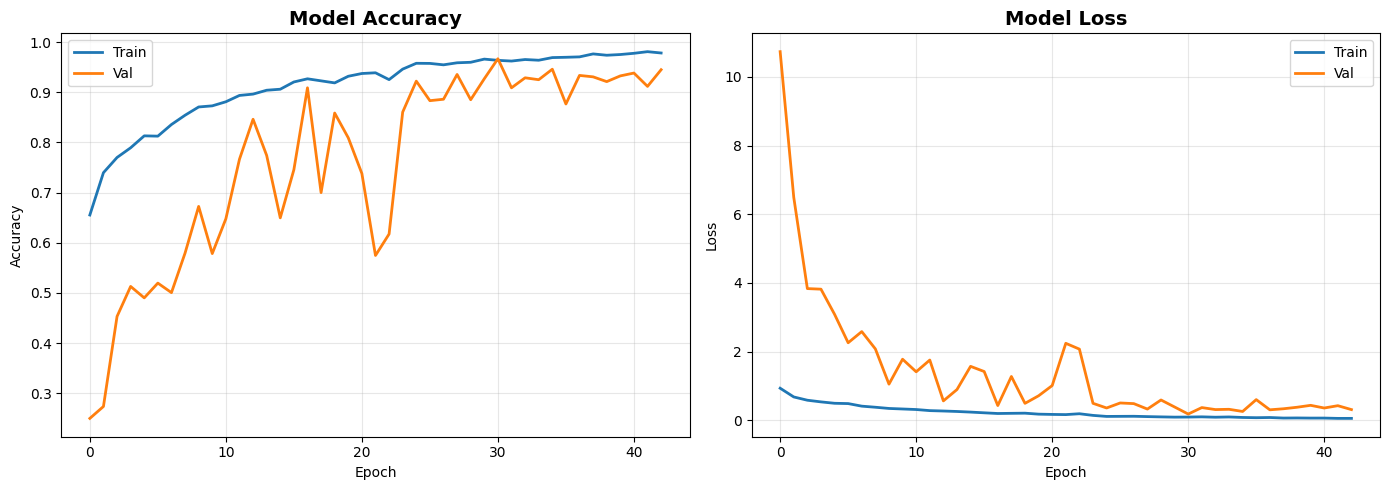


Test Accuracy: 0.9564
Test Loss: 0.1624

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9819    0.8930    0.9353       243
     healthy     0.9459    0.9900    0.9674       300
  meningioma     0.9435    0.9474    0.9455       247
   pituitary     0.9594    0.9848    0.9720       264

    accuracy                         0.9564      1054
   macro avg     0.9577    0.9538    0.9550      1054
weighted avg     0.9570    0.9564    0.9560      1054



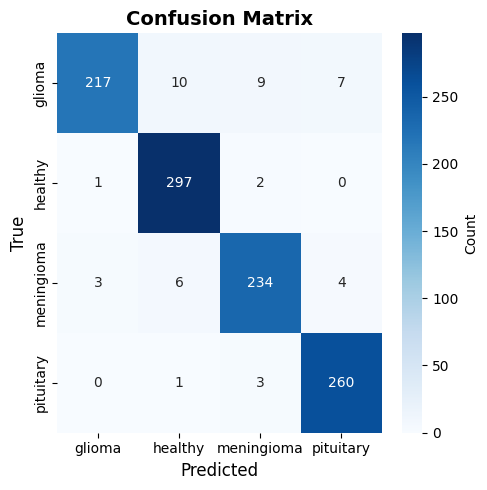


Final Training Accuracy: 0.9782
Final Validation Accuracy: 0.9449
Train-Val Gap: 0.0333
Status: Excellent generalization


In [16]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val', linewidth=2)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train', linewidth=2)
plt.plot(history.history['val_loss'], label='Val', linewidth=2)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
gap = train_acc - val_acc

print(f"\nFinal Training Accuracy: {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")
print(f"Train-Val Gap: {gap:.4f}")

if gap < 0.05:
    print("Status: Excellent generalization")
elif gap < 0.10:
    print("Status: Good generalization")
else:
    print("Status: Some overfitting detected")

In [10]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    model_cv = create_best_model()
    model_cv.compile(
        optimizer=keras.optimizers.Adam(5e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    model_cv.fit(
        X_train[train_idx], y_train[train_idx],
        validation_data=(X_train[val_idx], y_train[val_idx]),
        epochs=10,
        batch_size=32,
        verbose=0
    )
    
    _, acc = model_cv.evaluate(X_train[val_idx], y_train[val_idx], verbose=0)
    cv_scores.append(acc)

print("Cross-validation accuracies:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))


E0000 00:00:1766848401.129750      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/dropout_6_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-12-27 15:13:26.614810: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-12-27 15:

Cross-validation accuracies: [0.7682926654815674, 0.5676500797271729, 0.6531027555465698, 0.6826042532920837, 0.5371312499046326]
Mean CV accuracy: 0.6417562007904053


In [11]:
# Batch size experiment
for bs in [16, 32, 64]:
    model_exp = create_best_model()
    model_exp.compile(
        optimizer=keras.optimizers.Adam(5e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history_exp = model_exp.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=bs,
        verbose=0
    )
    print(f"Batch size {bs} → Val Acc: {history_exp.history['val_accuracy'][-1]:.4f}")


2025-12-27 15:18:18.107488: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Batch size 16 → Val Acc: 0.7284


2025-12-27 15:19:32.094227: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1766848776.052308      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_8_1/dropout_42_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-12-27 15

Batch size 32 → Val Acc: 0.7635


2025-12-27 15:20:40.883903: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1766848844.857207      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_9_1/dropout_48_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-12-27 15

Batch size 64 → Val Acc: 0.5869


In [17]:
print("=== Hyperparameter Experiment: Learning Rate ===")

for lr in [1e-3, 5e-4, 1e-4]:
    temp_model = create_best_model()
    temp_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    history_exp = temp_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=32,
        verbose=0
    )
    
    val_acc = history_exp.history['val_accuracy'][-1]
    val_loss = history_exp.history['val_loss'][-1]
    
    print(f"Learning rate {lr} → Val Accuracy: {val_acc:.4f}, Val Loss: {val_loss:.4f}")


=== Hyperparameter Experiment: Learning Rate ===


2025-12-27 15:30:46.743848: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1766849451.266680      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_10_1/dropout_54_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-12-27 1

Learning rate 0.001 → Val Accuracy: 0.8604, Val Loss: 0.4017


2025-12-27 15:31:56.089908: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1766849520.030967      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_11_1/dropout_60_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-12-27 1

Learning rate 0.0005 → Val Accuracy: 0.6230, Val Loss: 2.0938


2025-12-27 15:33:04.395698: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1766849588.343341      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_12_1/dropout_66_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-12-27 1

Learning rate 0.0001 → Val Accuracy: 0.5442, Val Loss: 3.0428


In [18]:
print("=== Hyperparameter Experiment: Number of Epochs ===")

for num_epochs in [10, 20, 30]:
    temp_model = create_best_model()
    temp_model.compile(
        optimizer=keras.optimizers.Adam(5e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    history_exp = temp_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=num_epochs,
        batch_size=32,
        verbose=0
    )
    
    val_acc = history_exp.history['val_accuracy'][-1]
    val_loss = history_exp.history['val_loss'][-1]
    
    print(f"Epochs {num_epochs} → Val Accuracy: {val_acc:.4f}, Val Loss: {val_loss:.4f}")


=== Hyperparameter Experiment: Number of Epochs ===


2025-12-27 15:35:01.188149: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1766849705.121712      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_13_1/dropout_72_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-12-27 1

Epochs 10 → Val Accuracy: 0.6334, Val Loss: 1.6901


2025-12-27 15:36:09.233614: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1766849773.203129      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_14_1/dropout_78_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-12-27 1

Epochs 20 → Val Accuracy: 0.7502, Val Loss: 1.2458


2025-12-27 15:38:16.798466: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1766849901.496076      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_15_1/dropout_84_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-12-27 1

Epochs 30 → Val Accuracy: 0.9316, Val Loss: 0.2880


In [19]:
print("=== Hyperparameter Experiment: Early Stopping ===")

# Without early stopping
temp_model_no_es = create_best_model()
temp_model_no_es.compile(
    optimizer=keras.optimizers.Adam(5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_no_es = temp_model_no_es.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=0
)
val_acc_no_es = history_no_es.history['val_accuracy'][-1]
val_loss_no_es = history_no_es.history['val_loss'][-1]
print(f"No EarlyStopping → Val Accuracy: {val_acc_no_es:.4f}, Val Loss: {val_loss_no_es:.4f}")

# With early stopping
temp_model_es = create_best_model()
temp_model_es.compile(
    optimizer=keras.optimizers.Adam(5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=0
)

history_es = temp_model_es.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)
val_acc_es = history_es.history['val_accuracy'][-1]
val_loss_es = history_es.history['val_loss'][-1]
print(f"With EarlyStopping → Val Accuracy: {val_acc_es:.4f}, Val Loss: {val_loss_es:.4f}")


=== Hyperparameter Experiment: Early Stopping ===


2025-12-27 15:42:41.375323: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1766850165.204492      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_16_1/dropout_90_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-12-27 1

No EarlyStopping → Val Accuracy: 0.8338, Val Loss: 0.7586


2025-12-27 15:44:49.772916: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1766850293.638214      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_17_1/dropout_96_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-12-27 1

With EarlyStopping → Val Accuracy: 0.8604, Val Loss: 0.5205
